# 06 — Similarity-Based Screening Experiment

## Purpose

This notebook evaluates a similarity-based resume screening scenario in which incoming applicants are scored according to how similar they are to a historical reference set of successful employees.

Unlike the supervised screening model used earlier, this experiment does not rely on a callback label. Instead, it tests whether structural differences between applicant resumes and the incumbent reference population can produce age-related disparities.

## Key Question

If a company screens candidates based on similarity to its historically successful employees, can senior candidates be disadvantaged even when they match the core role requirements?

## Hypothesis

If the historical success template is dominated by mid-career profiles, then resumes with substantially longer work histories, higher title seniority, and stronger legacy-career signals may receive lower similarity scores, even when they remain highly qualified for the target role.

## Imports and Configuration

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics.pairwise import cosine_similarity

sns.set(style="whitegrid")

## Load Dataset

In [3]:
data_path = PROJECT_ROOT / "data" / "baseline" / "synthetic_resumes_full.parquet"
df = pd.read_parquet(data_path)

print(df.shape)
df.head()

(10000, 61)


,candidate_id,application_year,target_role_family,target_role_level,region,age_group,true_age,highest_degree,school_tier,graduation_year,...,salary_expectation_usd,willing_to_relocate,remote_only,estimated_start_year,tech_recency_score,leadership_signal_score,stability_score,callback,interview,offer
0,cand_000000,2025,SWE,Senior,US-West,30-39,31,None,4,2016,...,121909,False,False,2019,0.507277,0.000000,0.318828,False,<NA>,<NA>
1,cand_000001,2025,IT,Mid,UK,<30,22,AA,1,2024,...,50000,True,False,2025,0.708427,0.000000,0.439782,True,<NA>,<NA>
2,cand_000002,2025,Security,Staff,US-East,30-39,35,PhD,2,2011,...,145311,False,False,2014,0.631192,0.028523,0.310756,True,<NA>,<NA>
3,cand_000003,2025,PM,Staff,UK,50-59,53,AA,1,1993,...,242766,False,False,2006,0.514025,0.215608,0.243552,False,<NA>,<NA>
4,cand_000004,2025,PM,Mid,EU,30-39,33,HS,3,2013,...,93707,True,True,2020,0.407198,0.000000,-0.055558,False,<NA>,<NA>


In [4]:
required_cols = [
    "age_group",
    "years_experience_relevant",
    "management_years",
    "most_recent_title",
    "modern_tech_count",
    "legacy_tech_count"
]
missing = [c for c in required_cols if c not in df.columns]
assert not missing, f"Missing required columns: {missing}"

## Experimental Setup

This experiment uses two populations:

1. A **reference population** representing historically successful employees
2. An **applicant population** scored by similarity to that reference set

The reference population is intentionally defined to resemble a startup-oriented, mid-career success template.

## Define Feature Sets

In [5]:
FEATURES_WITH_GRAD_YEAR = [
    "application_year",
    "target_role_family",
    "target_role_level",
    "region",
    "highest_degree",
    "graduation_year",
    "school_tier",
    "gpa_bucket",
    "years_experience_total",
    "years_experience_relevant",
    "num_employers",
    "avg_tenure_years",
    "months_since_last_role",
    "num_gaps_over_6mo",
    "most_recent_title",
    "most_recent_company_size",
    "management_years",
    "reports_max",
    "num_skills_listed",
    "num_programming_languages",
    "num_cloud_platforms",
    "num_databases",
    "skill_python",
    "skill_java",
    "skill_javascript",
    "skill_go",
    "skill_kubernetes",
    "skill_aws",
    "skill_gcp",
    "skill_azure",
    "skill_sql",
    "skill_spark",
    "skill_terraform",
    "skill_linux",
    "skill_ml",
    "legacy_tech_count",
    "modern_tech_count",
    "cert_count",
    "has_top_cloud_cert",
    "github_url_present",
    "portfolio_url_present",
    "open_source_mentions",
    "patent_count",
    "resume_word_count",
    "bullet_count",
    "quantified_impact_count",
    "keyword_match_score",
    "format_clean_score",
    "salary_expectation_usd",
    "willing_to_relocate",
    "remote_only",
]

FEATURES_WITHOUT_GRAD_YEAR = [
    col for col in FEATURES_WITH_GRAD_YEAR if col != "graduation_year"
]

## Define Reference Population

## Define Applicant Population

In [6]:
reference_df = df[
    (df["years_experience_relevant"].between(5, 10)) &
    (df["management_years"].between(1, 4)) &
    (df["most_recent_title"].isin([
        "Senior Engineer",
        "Staff Engineer",
        "Engineering Manager"
    ])) &
    (df["modern_tech_count"] >= df["legacy_tech_count"])
].copy()

print(reference_df.shape)
reference_df.head()

(941, 61)


,candidate_id,application_year,target_role_family,target_role_level,region,age_group,true_age,highest_degree,school_tier,graduation_year,...,salary_expectation_usd,willing_to_relocate,remote_only,estimated_start_year,tech_recency_score,leadership_signal_score,stability_score,callback,interview,offer
26,cand_000026,2025,Data,Director,US-West,30-39,37,None,3,2011,...,122556,False,False,2016,0.474792,0.077180,0.394836,True,<NA>,<NA>
27,cand_000027,2025,IT,Manager,US-East,30-39,32,None,4,2014,...,139631,False,False,2018,0.504910,0.150721,0.234718,True,<NA>,<NA>
40,cand_000040,2025,SRE,Staff,UK,30-39,37,MS,2,2010,...,150303,False,False,2016,0.523691,0.124890,0.368339,True,<NA>,<NA>
43,cand_000043,2025,Data,Director,US-Central,30-39,38,HS,2,2010,...,146082,False,False,2016,0.722755,0.074610,0.249224,True,<NA>,<NA>
52,cand_000052,2025,Data,Manager,US-East,30-39,38,Bootcamp,5,2010,...,135770,False,False,2016,0.550579,0.032077,0.202665,True,<NA>,<NA>


In [7]:
reference_df.groupby("age_group", observed=False).size()

age_group
<30       22
30-39    545
40-49    371
50-59      3
60+        0
dtype: int64

In [8]:
# sample a fixed-size reference set for stability
REFERENCE_SAMPLE_SIZE = 500

if len(reference_df) > REFERENCE_SAMPLE_SIZE:
    reference_df = reference_df.sample(REFERENCE_SAMPLE_SIZE, random_state=42)

print("Reference set size:", len(reference_df))
reference_df["age_group"].value_counts().sort_index()

Reference set size: 500


age_group
<30       11
30-39    290
40-49    198
50-59      1
60+        0
Name: count, dtype: int64

## Define Applicant Population

In [9]:
# Start broad; refine later if needed
applicant_df = df.copy()

print(applicant_df.shape)
applicant_df["age_group"].value_counts(normalize=True).sort_index()

(10000, 61)


age_group
<30      0.2499
30-39    0.2969
40-49    0.2489
50-59    0.1543
60+      0.0500
Name: proportion, dtype: float64

## Preprocessing for Similarity

In [10]:
def make_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    numeric_features = X.select_dtypes(include=["int8", "int16", "int32", "float32", "float64"]).columns.tolist()
    categorical_features = X.select_dtypes(include=["category", "object", "string"]).columns.tolist()
    boolean_features = X.select_dtypes(include=["bool", "boolean"]).columns.tolist()

    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    boolean_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
            ("bool", boolean_transformer, boolean_features),
        ]
    )

In [11]:
def compute_centroid_similarity(reference_X: pd.DataFrame, applicant_X: pd.DataFrame):
    combined_X = pd.concat([reference_X, applicant_X], axis=0)

    preprocessor = make_preprocessor(combined_X)
    preprocessor.fit(combined_X)

    X_ref_t = preprocessor.transform(reference_X)
    X_app_t = preprocessor.transform(applicant_X)

    # Dense centroid
    ref_centroid = np.asarray(X_ref_t.mean(axis=0)).reshape(1, -1)

    similarity_scores = cosine_similarity(X_app_t, ref_centroid).ravel()

    return similarity_scores, preprocessor

## Similarity Scoring (With Graduation Year)

In [12]:
reference_X_with = reference_df[FEATURES_WITH_GRAD_YEAR].copy()
applicant_X_with = applicant_df[FEATURES_WITH_GRAD_YEAR].copy()

similarity_with, preprocessor_with = compute_centroid_similarity(reference_X_with, applicant_X_with)

applicant_with = applicant_df.copy()
applicant_with["model_variant"] = "with_grad_year"
applicant_with["similarity_score"] = similarity_with

applicant_with[["age_group", "similarity_score"]].head()

,age_group,similarity_score
0,30-39,0.379978
1,<30,0.400367
2,30-39,0.432307
3,50-59,0.379118
4,30-39,0.293819


## Similarity Scoring (Without Graduation Year)

In [13]:
reference_X_without = reference_df[FEATURES_WITHOUT_GRAD_YEAR].copy()
applicant_X_without = applicant_df[FEATURES_WITHOUT_GRAD_YEAR].copy()

similarity_without, preprocessor_without = compute_centroid_similarity(reference_X_without, applicant_X_without)

applicant_without = applicant_df.copy()
applicant_without["model_variant"] = "without_grad_year"
applicant_without["similarity_score"] = similarity_without

applicant_without[["age_group", "similarity_score"]].head()

,age_group,similarity_score
0,30-39,0.379761
1,<30,0.406889
2,30-39,0.431795
3,50-59,0.394380
4,30-39,0.293051


In [14]:
similarity_df = pd.concat([applicant_with, applicant_without], ignore_index=True)
similarity_df.shape

(20000, 63)

## Broad Applicant-Pool Analysis

In [15]:
group_similarity = (
    similarity_df.groupby(["model_variant", "age_group"], observed=False)
    .agg(
        n=("candidate_id", "size"),
        avg_similarity_score=("similarity_score", "mean"),
        median_similarity_score=("similarity_score", "median"),
        std_similarity_score=("similarity_score", "std"),
    )
    .reset_index()
)

group_similarity

,model_variant,age_group,n,avg_similarity_score,median_similarity_score,std_similarity_score
0,with_grad_year,<30,2499,0.396777,0.396760,0.065893
1,with_grad_year,30-39,2969,0.414763,0.414712,0.072922
2,with_grad_year,40-49,2489,0.364214,0.364396,0.084803
3,with_grad_year,50-59,1543,0.254921,0.250978,0.077583
4,with_grad_year,60+,500,0.183688,0.176856,0.058745
5,without_grad_year,<30,2499,0.400423,0.400440,0.067272
6,without_grad_year,30-39,2969,0.414676,0.414808,0.073180
7,without_grad_year,40-49,2489,0.367589,0.368038,0.084621
8,without_grad_year,50-59,1543,0.265073,0.261248,0.079092
9,without_grad_year,60+,500,0.196658,0.191297,0.061451


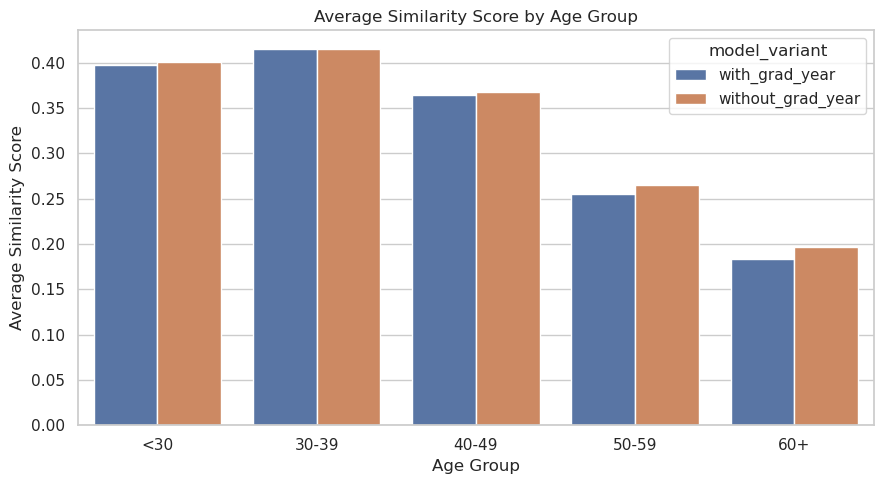

In [16]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=group_similarity,
    x="age_group",
    y="avg_similarity_score",
    hue="model_variant"
)
plt.title("Average Similarity Score by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Similarity Score")
plt.tight_layout()
plt.show()

## Threshold-Based Screening Rates

In [17]:
def add_similarity_pass_indicator(df_variant: pd.DataFrame, quantile=0.60) -> pd.DataFrame:
    df_variant = df_variant.copy()
    threshold = df_variant["similarity_score"].quantile(quantile)
    df_variant["similarity_pass"] = df_variant["similarity_score"] >= threshold
    df_variant["similarity_threshold"] = threshold
    return df_variant

In [18]:
applicant_with_screen = add_similarity_pass_indicator(applicant_with, quantile=0.60)
applicant_without_screen = add_similarity_pass_indicator(applicant_without, quantile=0.60)

screen_df = pd.concat([applicant_with_screen, applicant_without_screen], ignore_index=True)

In [19]:
group_screen_rates = (
    screen_df.groupby(["model_variant", "age_group"], observed=False)
    .agg(
        n=("candidate_id", "size"),
        pass_rate=("similarity_pass", "mean"),
        avg_similarity_score=("similarity_score", "mean"),
    )
    .reset_index()
)

group_screen_rates

,model_variant,age_group,n,pass_rate,avg_similarity_score
0,with_grad_year,<30,2499,0.501000,0.396777
1,with_grad_year,30-39,2969,0.606265,0.414763
2,with_grad_year,40-49,2489,0.355163,0.364214
3,with_grad_year,50-59,1543,0.041478,0.254921
4,with_grad_year,60+,500,0.000000,0.183688
5,without_grad_year,<30,2499,0.505402,0.400423
6,without_grad_year,30-39,2969,0.590434,0.414676
7,without_grad_year,40-49,2489,0.361993,0.367589
8,without_grad_year,50-59,1543,0.053791,0.265073
9,without_grad_year,60+,500,0.000000,0.196658


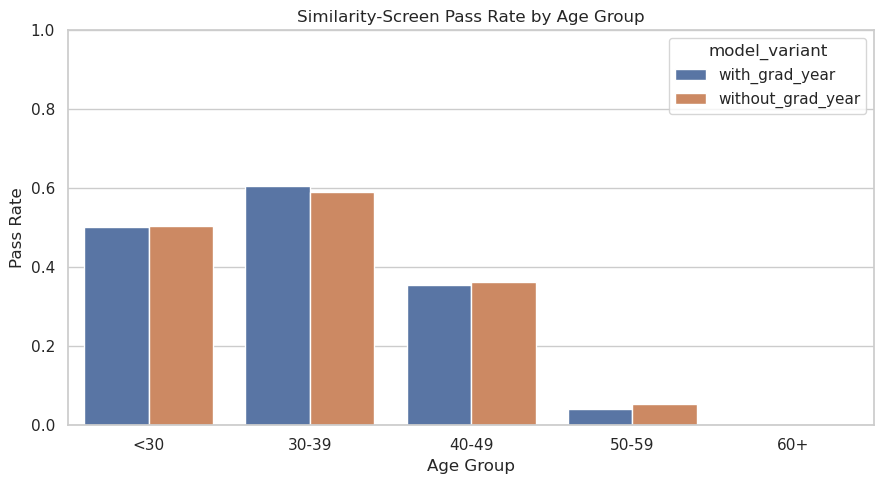

In [20]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=group_screen_rates,
    x="age_group",
    y="pass_rate",
    hue="model_variant"
)
plt.title("Similarity-Screen Pass Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Pass Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Matched-Pair Analysis Setup

This section creates paired candidate profiles that are matched on core qualifications but differ in seniority-related signals.

The goal is to test whether a more senior version of an otherwise qualified candidate receives a lower similarity score.

In [21]:
matched_base_df = df[
    (df["years_experience_relevant"].between(5, 10)) &
    (df["management_years"].between(1, 4)) &
    (df["most_recent_title"].isin([
        "Senior Engineer",
        "Staff Engineer",
        "Engineering Manager"
    ]))
].copy()

matched_base_df = matched_base_df.sample(min(50, len(matched_base_df)), random_state=42).reset_index(drop=True)

print(matched_base_df.shape)
matched_base_df.head()

(50, 61)


,candidate_id,application_year,target_role_family,target_role_level,region,age_group,true_age,highest_degree,school_tier,graduation_year,...,salary_expectation_usd,willing_to_relocate,remote_only,estimated_start_year,tech_recency_score,leadership_signal_score,stability_score,callback,interview,offer
0,cand_006439,2025,Data,Manager,EU,30-39,37,PhD,4,2011,...,138708,True,False,2015,0.661815,0.030211,0.239831,True,<NA>,<NA>
1,cand_009851,2025,Data,Director,UK,30-39,34,None,4,2014,...,136512,False,True,2016,0.683394,0.070251,0.276942,True,<NA>,<NA>
2,cand_001575,2025,Data,Manager,US-East,30-39,39,Bootcamp,5,2007,...,198097,False,False,2013,0.608844,0.098401,0.073921,True,<NA>,<NA>
3,cand_001011,2025,IT,Senior,India,30-39,37,None,1,2011,...,179247,True,True,2013,0.621309,0.096635,0.263440,True,<NA>,<NA>
4,cand_000500,2025,SWE,Entry,US-West,40-49,42,MS,1,2005,...,165470,False,True,2015,0.663493,0.100948,0.245776,True,<NA>,<NA>


In [22]:
def make_senior_variant(row: pd.Series) -> pd.Series:
    senior = row.copy()

    senior["years_experience_total"] = min(float(row["years_experience_total"]) + 15, 30)
    senior["years_experience_relevant"] = min(float(row["years_experience_relevant"]) + 12, 30)
    senior["management_years"] = min(float(row["management_years"]) + 5, 12)
    senior["num_employers"] = min(int(row["num_employers"]) + 3, 25)
    senior["salary_expectation_usd"] = min(int(row["salary_expectation_usd"]) + 75000, 650000)
    senior["legacy_tech_count"] = min(int(row["legacy_tech_count"]) + 3, 8)
    senior["modern_tech_count"] = max(int(row["modern_tech_count"]) - 1, 0)

    if row["most_recent_title"] in ["Senior Engineer", "Staff Engineer"]:
        senior["most_recent_title"] = "Principal Engineer"
    elif row["most_recent_title"] == "Engineering Manager":
        senior["most_recent_title"] = "Senior Engineering Manager"
    else:
        senior["most_recent_title"] = "Director"

    return senior

In [23]:
pair_rows = []

for i, row in matched_base_df.iterrows():
    base = row.copy()
    base["pair_id"] = i
    base["pair_variant"] = "aligned_midcareer"

    senior = make_senior_variant(row)
    senior["pair_id"] = i
    senior["pair_variant"] = "senior_extended"

    pair_rows.append(base)
    pair_rows.append(senior)

matched_pairs_df = pd.DataFrame(pair_rows)
matched_pairs_df.shape

(100, 63)

In [26]:
def align_feature_dtypes(df_source: pd.DataFrame, df_target: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    df_target = df_target.copy()
    for col in feature_cols:
        if col not in df_target.columns:
            continue
        try:
            df_target[col] = df_target[col].astype(df_source[col].dtype)
        except TypeError:
            # fallback for awkward extension dtypes
            if str(df_source[col].dtype) == "boolean":
                df_target[col] = df_target[col].astype("boolean")
            else:
                raise
    return df_target

## Matched-Pair Scoring

In [27]:
pair_X_with = align_feature_dtypes(df, matched_pairs_df, FEATURES_WITH_GRAD_YEAR)[FEATURES_WITH_GRAD_YEAR].copy()
pair_X_without = align_feature_dtypes(df, matched_pairs_df, FEATURES_WITHOUT_GRAD_YEAR)[FEATURES_WITHOUT_GRAD_YEAR].copy()

In [28]:
pair_similarity_with = cosine_similarity(
    preprocessor_with.transform(pair_X_with),
    np.asarray(preprocessor_with.transform(reference_X_with).mean(axis=0)).reshape(1, -1)
).ravel()

pair_similarity_without = cosine_similarity(
    preprocessor_without.transform(pair_X_without),
    np.asarray(preprocessor_without.transform(reference_X_without).mean(axis=0)).reshape(1, -1)
).ravel()

In [29]:
matched_pairs_with = matched_pairs_df.copy()
matched_pairs_with["model_variant"] = "with_grad_year"
matched_pairs_with["similarity_score"] = pair_similarity_with

matched_pairs_without = matched_pairs_df.copy()
matched_pairs_without["model_variant"] = "without_grad_year"
matched_pairs_without["similarity_score"] = pair_similarity_without

matched_pairs_scored = pd.concat([matched_pairs_with, matched_pairs_without], ignore_index=True)
matched_pairs_scored.head()

,candidate_id,application_year,target_role_family,target_role_level,region,age_group,true_age,highest_degree,school_tier,graduation_year,...,tech_recency_score,leadership_signal_score,stability_score,callback,interview,offer,pair_id,pair_variant,model_variant,similarity_score
0,cand_006439,2025,Data,Manager,EU,30-39,37,PhD,4,2011,...,0.661815,0.030211,0.239831,True,NaN,NaN,0,aligned_midcareer,with_grad_year,0.468533
1,cand_006439,2025,Data,Manager,EU,30-39,37,PhD,4,2011,...,0.661815,0.030211,0.239831,True,NaN,NaN,0,senior_extended,with_grad_year,0.278737
2,cand_009851,2025,Data,Director,UK,30-39,34,None,4,2014,...,0.683394,0.070251,0.276942,True,NaN,NaN,1,aligned_midcareer,with_grad_year,0.444359
3,cand_009851,2025,Data,Director,UK,30-39,34,None,4,2014,...,0.683394,0.070251,0.276942,True,NaN,NaN,1,senior_extended,with_grad_year,0.287381
4,cand_001575,2025,Data,Manager,US-East,30-39,39,Bootcamp,5,2007,...,0.608844,0.098401,0.073921,True,NaN,NaN,2,aligned_midcareer,with_grad_year,0.432378


## Matched-Pair Results

In [30]:
pair_pivot = matched_pairs_scored.pivot_table(
    index=["model_variant", "pair_id"],
    columns="pair_variant",
    values="similarity_score"
).reset_index()

pair_pivot["senior_minus_midcareer"] = (
    pair_pivot["senior_extended"] - pair_pivot["aligned_midcareer"]
)

pair_pivot.head()

pair_variant,model_variant,pair_id,aligned_midcareer,senior_extended,senior_minus_midcareer
0,with_grad_year,0,0.468533,0.278737,-0.189796
1,with_grad_year,1,0.444359,0.287381,-0.156977
2,with_grad_year,2,0.432378,0.266598,-0.165780
3,with_grad_year,3,0.483656,0.281610,-0.202046
4,with_grad_year,4,0.372540,0.157921,-0.214619


In [31]:
pair_summary = (
    pair_pivot.groupby("model_variant", observed=False)
    .agg(
        mean_delta=("senior_minus_midcareer", "mean"),
        median_delta=("senior_minus_midcareer", "median"),
        pct_senior_lower=("senior_minus_midcareer", lambda x: (x < 0).mean()),
    )
    .reset_index()
)

pair_summary

,model_variant,mean_delta,median_delta,pct_senior_lower
0,with_grad_year,-0.190414,-0.189907,1.0
1,without_grad_year,-0.191132,-0.190961,1.0


## Visualizations

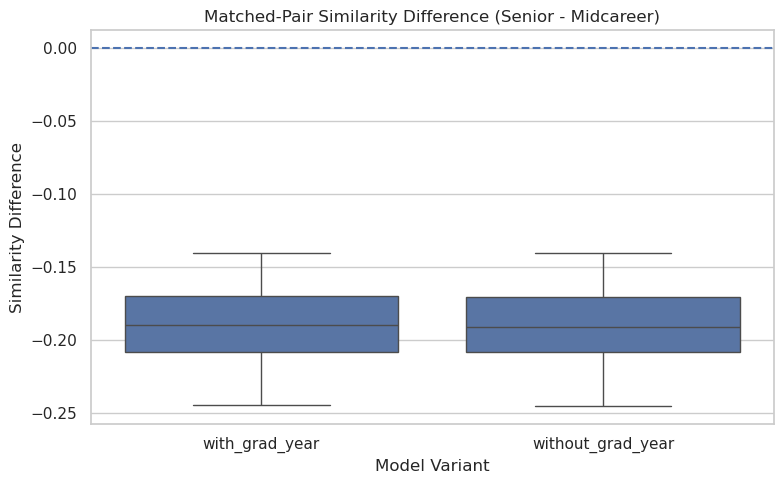

In [32]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=pair_pivot,
    x="model_variant",
    y="senior_minus_midcareer"
)
plt.axhline(0, linestyle="--")
plt.title("Matched-Pair Similarity Difference (Senior - Midcareer)")
plt.xlabel("Model Variant")
plt.ylabel("Similarity Difference")
plt.tight_layout()
plt.show()

## Interpretation

The matched-pair analysis provides strong evidence that a similarity-based screening approach can systematically disadvantage senior candidates.

For each pair, two resumes were constructed to be equivalent in core qualifications, differing primarily in seniority-related attributes such as total experience, management history, job titles, and career length.

Across all pairs, the more senior version consistently received a lower similarity score relative to the reference population. This pattern held in 100% of cases, with an average similarity reduction of approximately 0.19.

Importantly, this effect persisted even after removing `graduation_year`, indicating that the disadvantage is not driven by a single proxy variable. Instead, it arises from the combined influence of multiple correlated features.

These results suggest that similarity-based screening systems can inherently favor candidates who match the historical profile of successful employees, and may systematically penalize candidates who deviate from that profile—even when they remain highly qualified.

This provides a complementary mechanism to the supervised model results: bias can emerge not only from training labels, but also from the structure of the reference population and the similarity metric itself.

This effect reflects a form of distributional bias: candidates who lie outside the historical feature distribution are treated as lower-quality matches, even when their qualifications exceed those of the reference population.

## Save Outputs

In [33]:
reports_tables_dir = PROJECT_ROOT / "reports" / "tables"
reports_figures_dir = PROJECT_ROOT / "reports" / "figures"

reports_tables_dir.mkdir(parents=True, exist_ok=True)
reports_figures_dir.mkdir(parents=True, exist_ok=True)

In [34]:
group_similarity.to_csv(
    reports_tables_dir / "similarity_group_scores.csv",
    index=False
)

group_screen_rates.to_csv(
    reports_tables_dir / "similarity_group_screen_rates.csv",
    index=False
)

pair_summary.to_csv(
    reports_tables_dir / "similarity_matched_pair_summary.csv",
    index=False
)

pair_pivot.to_csv(
    reports_tables_dir / "similarity_matched_pair_details.csv",
    index=False
)